Hi

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Bank Customer Churn Analysis
</div>


## Project Overview

This project aims to analyze customer data and identify factors
associated with customer churn.

## Objective

The objective of this notebook is to understand the structure,
content, and quality of the raw dataset before data cleaning
and exploratory data analysis.

In [3]:
import pandas as pd
pd.set_option("display.max_columns", None)


## 2. Load Dataset

### 2.1 Check Available Sheets

In [4]:
excel_file = pd.ExcelFile(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx"
)

print(excel_file.sheet_names)

['Customer_Info', 'Account_Info']


### 2.2 Load the Customer_Info and Account_Info Sheets

In [5]:
# Read Customer_Info sheet
df_customer = pd.read_excel(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx",
    sheet_name="Customer_Info"
)

# Read Account_Info sheet
df_account = pd.read_excel(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx",
    sheet_name="Account_Info"
)

print("Customer_Info:")
display(df_customer.head())

print("Account_Info:")
display(df_account.head())

Customer_Info:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


Account_Info:


,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Dataset Overview
</div>

## 3. Dataset Overview

In [6]:
# Check the number of rows and columns on Customer_Info sheet

print("Number of rows:", df_customer.shape[0])
print("Number of columns:", df_customer.shape[1])

# Display column names of customer sheet

print("Column names:")
print(df_customer.columns.tolist())

# Display dataset information

print("Customer_Info sheet information")
df_customer.info()



# Check the number of rows and columns on Account_Info sheet 

print("\nNumber of rows:", df_account.shape[0])
print("Number of columns:", df_account.shape[1])

# Display column names of account sheet

print("Column names:")
print(df_account.columns.tolist())

# Display dataset information

print("Account_Info sheet information")
df_account.info()

Number of rows: 10001
Number of columns: 8
Column names:
['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'EstimatedSalary']
Customer_Info sheet information
<class 'pandas.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10001 non-null  int64  
 1   Surname          9998 non-null   str    
 2   CreditScore      10001 non-null  int64  
 3   Geography        10001 non-null  str    
 4   Gender           10001 non-null  str    
 5   Age              9998 non-null   float64
 6   Tenure           10001 non-null  int64  
 7   EstimatedSalary  10001 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 625.2 KB

Number of rows: 10002
Number of columns: 7
Column names:
['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure', 'IsActiveMember', 'Exited']
Account_Info sheet information
<class 'pan

#### Based on data types:
The Age column is stored as the float64 data type. This may be due to the presence of missing values. The data type and values should be reviewed during the data-cleaning process.

The EstimatedSalary column is stored as a string/object data type, although salary is expected to be a numerical variable. The column should be examined for formatting issues and converted to an appropriate numerical data type during data cleaning.

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Data Quality Check
</div>

## 4. Data Quality Assessment

In [7]:
# Check missing values

missing_values_customer = df_customer.isnull().sum()

print("Missing values of customer sheet:")
print(missing_values_customer)


missing_values_account = df_account.isnull().sum()

print("\nMissing values of account sheet:")
print(missing_values_account)


Missing values of customer sheet:
CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
dtype: int64

Missing values of account sheet:
CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64


The Customer_Info sheet contains missing values in two columns: Surname and Age

The Account_Info sheet does not contain any missing values.

Therefore, further data cleaning is required for the Surname and Age columns. The appropriate treatment for these missing values will be determined after examining the affected records and considering the nature and analytical importance of each variable.



In [8]:
# Check for duplicated rows in both sheets

duplicate_rows_customer = df_customer.duplicated().sum()

print("Number of duplicated rows in customer_info sheet:", duplicate_rows_customer)

duplicate_rows_account = df_account.duplicated().sum()
print("\nNumber of duplicated rows in account_info sheet:", duplicate_rows_account)

# Display all duplicated rows
display(
    df_customer[
        df_customer.duplicated(keep=False)
    ]
)

display(
    df_account[
        df_account.duplicated(keep=False)
    ]
)

Number of duplicated rows in customer_info sheet: 1

Number of duplicated rows in account_info sheet: 2


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78


,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
10000,15628319,€130142.79,1,No,4,No,0
10001,15628319,€130142.79,1,No,4,No,0


In [9]:
# Check for duplicated CustomerId values in both sheets

print(
    "Duplicated CustomerId values in Customer_Info:",
    df_customer["CustomerId"].duplicated().sum()
)

print(
    "Duplicated CustomerId values in Account_Info:",
    df_account["CustomerId"].duplicated().sum()
)

Duplicated CustomerId values in Customer_Info: 1
Duplicated CustomerId values in Account_Info: 2


In [10]:
# Check the number of unique values in each column in 2 sheet 

unique_values_customer = df_customer.nunique()

print("Number of unique values in customer_info sheet:")
print(unique_values_customer)

# Check the number of the unique values in each column

unique_values_account = df_account.nunique()
print("\nNumber of unique values in account_info sheet:")
print(unique_values_account)

Number of unique values in customer_info sheet:
CustomerId         10000
Surname             2932
CreditScore          460
Geography              5
Gender                 2
Age                   70
Tenure                11
EstimatedSalary     9997
dtype: int64

Number of unique values in account_info sheet:
CustomerId        10000
Balance            6382
NumOfProducts         4
HasCrCard             2
Tenure               11
IsActiveMember        2
Exited                2
dtype: int64


The Customer_Info sheet contains 1 duplicated row. The sheet has 10,001 rows but only 10,000 unique CustomerId values. This result is consistent with the duplicate check and indicates that one customer record is duplicated.

The Account_Info sheet contains 2 duplicated rows. The sheet has 10,002 rows but only 10,000 unique CustomerId values. This result is consistent with the duplicate check and indicates that two customers record are duplicated.

Most categorical variables have a limited number of unique values. For example, Gender has 2 unique values, while HasCrCard, IsActiveMember, and Exited also have 2 unique values. These result are generally valid for binary variables.

The EstimatedSalary column has 9,997 unique values, indicating that most salary values are distinct. However, this column is currently stored as a string and should be checked for formatting issues before being converted to a numerical data type.

In [11]:
# Examine the values in EstimatedSalary

print(
    df_customer["EstimatedSalary"]
    .head(20)
)

0     €101348.88
1     €112542.58
2     €113931.57
3      €93826.63
4       €79084.1
5     €149756.71
6       €10062.8
7     €119346.88
8       €74940.5
9      €71725.73
10     €80181.12
11     €76390.01
12     €26260.98
13    €190857.79
14     €65951.65
15     €64327.26
16      €5097.67
17     €14406.41
18    €158684.81
19     €54724.03
Name: EstimatedSalary, dtype: str


The `EstimatedSalary` column is stored as a string data type because each value contains the euro currency symbol (`€`). As a result, the values cannot be directly converted to a numerical data type. The currency symbol should be removed, and the column should be converted to a numeric data type during the data-cleaning process.


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Cleaning Data
</div>

#### Standardize column names

In [12]:
print(df_customer.columns.tolist())
print(df_account.columns.tolist())

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'EstimatedSalary']
['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure', 'IsActiveMember', 'Exited']


#### Correct `Balance` data type

In [13]:
# Convert Balance from string to numeric
df_account["Balance"] = (
    df_account["Balance"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Check data type again
print(df_account["Balance"].dtype)

float64


`Georaphy`

In [14]:
df_customer["Geography"].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1656
FRA        1618
Name: count, dtype: int64

In [15]:
df_customer["Geography"] = df_customer["Geography"].replace({
    "French": "France",
    "FRA": "France"
})

##### Correct EstimatedSalary data type 
Convert `EstimatedSalary` from string to numeric

In [16]:
# Remove the euro symbol and leading/trailing whitespace
df_customer["EstimatedSalary"] = (
    df_customer["EstimatedSalary"]
    .astype("string")
    .str.replace("€", "", regex=False)
    .str.strip()
)

# Convert EstimatedSalary from string to numeric
df_customer["EstimatedSalary"] = pd.to_numeric(
    df_customer["EstimatedSalary"],
    errors="coerce"
)

# Confirm the data type after conversion
print(
    "Data type of EstimatedSalary:",
    df_customer["EstimatedSalary"].dtype
)

# Display rows containing NaN values
print(
    "\nRows with NaN values:"
)
display(
    df_customer[
        df_customer["EstimatedSalary"].isna()
    ]
)

# Count the number of NaN values
print(
    "\nNumber of NaN values:",
    df_customer["EstimatedSalary"].isna().sum()
)

Data type of EstimatedSalary: Float64

Rows with NaN values:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary



Number of NaN values: 0


In [194]:

df_customer[df_customer["EstimatedSalary"] < 0][
    ["CustomerId", "EstimatedSalary"]
]

,CustomerId,EstimatedSalary
28,15728693,-999999.0
121,15580203,-999999.0
9389,15756954,-999999.0


In [215]:
import numpy as np
df_customer["EstimatedSalary"] = df_customer["EstimatedSalary"].replace(
    -999999,
    np.nan
)

df_customer["EstimatedSalary"].isna().sum()

np.int64(3)

In [254]:
#Replace invalid columns with the mean
median_salary = df_customer["EstimatedSalary"].median()

df_customer["EstimatedSalary"] = df_customer["EstimatedSalary"].fillna(
    median_salary
)

df_customer["EstimatedSalary"].describe()

count          10000.0
mean     100092.265795
std        57510.14643
min              11.58
25%           51002.11
50%          100236.02
75%        149388.2475
max          199992.48
Name: EstimatedSalary, dtype: Float64

Before converting the data type, the `EstimatedSalary` column was checked for missing and `NaN` values. No missing or `NaN` values were found. Howerver,three invalid values below 0 were identified. These invalid values will be replaced with the mean of `EstimatedSalary`. 

The € symbol and leading or trailing whitespace were then removed from the column. Next, the `EstimatedSalary` column was converted from string to numeric using pd.to_numeric().

After the conversion, the data type was confirmed as float64. No `NaN` values were found, indicating that all values were successfully converted to numeric format.

#### Handle Missing values
In this project, `Surname` is not considered relevant to churn analysis and will not be used as a variable. Therefore, missing values in this column will be replaced with `Unknown`

Handle Missing values in `Age`
. The `Age` column contains 3 missing values. Since `Age` is a numerical variable and the number of missing values is small, the missing values are imputed using the median age. The median is selected because it is less sensitive to extreme values than the mean

In [273]:
# Missing values of Surname column
df_customer["Surname"] = (
    df_customer["Surname"]
    .fillna("Unknown")
)


print(
    "Missing values in Surname:",
    df_customer["Surname"].isna().sum()
)

# Missing values of Age

display(df_customer["Age"].describe())

# Calculate the median age
age_median = df_customer["Age"].median()

print("Median age:", age_median)

# Fill missing values with the median
df_customer["Age"] = (
    df_customer["Age"]
    .fillna(age_median)
)

# Convert Age to integer
df_customer["Age"] = (
    df_customer["Age"]
    .astype("Int64")
)

# Check missing values after treatment
print(
    "Missing values in Age:",
    df_customer["Age"].isna().sum()
)


Missing values in Surname: 0


count      10000.0
mean       38.9215
std      10.487552
min           18.0
25%           32.0
50%           37.0
75%           44.0
max           92.0
Name: Age, dtype: Float64

Median age: 37.0
Missing values in Age: 0


#### Remove Duplicate Rows

In [274]:
# Remove completely duplicated rows
df_account = df_account.drop_duplicates()

df_customer = df_customer.drop_duplicates()

# Check again to confirm that have no duplicated
print(
    "Duplicated rows after cleaning:",
    df_account.duplicated().sum()
)

print(
    "Duplicated CustomerId after cleaning:",
    df_account["CustomerId"].duplicated().sum()
)

Duplicated rows after cleaning: 0
Duplicated CustomerId after cleaning: 0


#### Validate cleaned data
After completing the data cleaning process, the datasets were re-evaluated to comfirm that missing values, duplicate records, and data type issues had been probably addressed.

In [275]:
print("Customer_Info - Data Validation")

print("\nDataset shape:")
print(df_customer.shape)

print("\nMissing values:")
print(df_customer.isnull().sum())

print("\nDuplicated rows:")
print(df_customer.duplicated().sum())

print("\nDuplicated CustomerId values:")
print(df_customer["CustomerId"].duplicated().sum())

print("\nData types:")
print(df_customer.dtypes)

Customer_Info - Data Validation

Dataset shape:
(10000, 8)

Missing values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  Int64
Tenure               int64
EstimatedSalary    Float64
dtype: object


In [276]:
print("Account_Info - Data Validation")

print("\nDataset shape:")
print(df_account.shape)

print("\nMissing values:")
print(df_account.isnull().sum())

print("\nDuplicated rows:")
print(df_account.duplicated().sum())

print("\nDuplicated CustomerId values:")
print(df_account["CustomerId"].duplicated().sum())

print("\nData types:")
print(df_account.dtypes)

Account_Info - Data Validation

Dataset shape:
(10000, 7)

Missing values:
CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId          int64
Balance           float64
NumOfProducts       int64
HasCrCard             str
Tenure              int64
IsActiveMember        str
Exited              int64
dtype: object


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
   Data Integration 
</div>

The `Customer_Info` and `Account_Info` datasets contain different information about the same customers. The two datasets will be integrated using `CustomerId` as a common key.
Before merging, the relationship between the datasets and the quality of the merge key will be validated.

#### Identify the Common Key

In [277]:
# Check whether CustomerId exists in both datasets

print(
    "CustomerId in Customer_Info:",
    "CustomerId" in df_customer.columns
)

print(
    "CustomerId in Account_Info:",
    "CustomerId" in df_account.columns
)

CustomerId in Customer_Info: True
CustomerId in Account_Info: True


Check the Common Key. The `CustomerId` column was confirmed to exist in both the `Customer_Info` and `Account_Info` datasets. Therefore, it can be used as the common key to merge the two datasets.


In [278]:
# Check the data type of CustomerId

print(
    "Customer_Info CustomerId type:",
    df_customer["CustomerId"].dtype
)

print(
    "Account_Info CustomerId type:",
    df_account["CustomerId"].dtype
)

Customer_Info CustomerId type: int64
Account_Info CustomerId type: int64


#### Check Matching and Unmatched Customer

In [279]:
# Create sets of CustomerId values

customer_ids = set(
    df_customer["CustomerId"]
)

account_ids = set(
    df_account["CustomerId"]
)

In [280]:
# Count CustomerIds appearing in both datasets

common_ids = (
    customer_ids
    .intersection(account_ids)
)

print(
    "Number of matching CustomerIds:",
    len(common_ids)
)

Number of matching CustomerIds: 10000


#### Merge both Datasets

In [281]:
# Merge the two datasets

df_merged = pd.merge(
    df_customer,
    df_account,
    on="CustomerId",
    how="inner",
    validate="one_to_one"
)

In [264]:
# Display the first five rows

display(
    df_merged.head()
)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42,2,101348.88,0.00,1,Yes,2,Yes,1
1,15647311,Hill,608,Spain,Female,41,1,112542.58,83807.86,1,Yes,1,Yes,0
2,15619304,Onio,502,France,Female,42,8,113931.57,159660.80,3,No,8,No,1
3,15701354,Boni,699,France,Female,39,1,93826.63,0.00,2,No,1,No,0
4,15737888,Mitchell,850,Spain,Female,43,2,79084.1,125510.82,1,Yes,2,Yes,0


In [282]:
# Keep Tenure_x and rename it to Tenure

df_merged = (
    df_merged
    .drop(columns="Tenure_y")
    .rename(
        columns={
            "Tenure_x": "Tenure"
        }
    )
)

In [283]:
# Check the shape of the merged dataset

print(
    "Merged dataset shape:",
    df_merged.shape
)

Merged dataset shape: (10000, 13)


#### Validate the Merged Dataset

In [284]:
print("Merged Dataset Validation")

print("\nDataset shape:")
print(
    df_merged.shape
)

print("\nMissing values:")
print(
    df_merged.isnull().sum()
)

print("\nDuplicated rows:")
print(
    df_merged.duplicated().sum()
)

print("\nDuplicated CustomerId values:")
print(
    df_merged["CustomerId"]
    .duplicated()
    .sum()
)

print("\nData types:")
print(
    df_merged.dtypes
)

print(
    "Number of unique CustomerIds:",
    df_merged["CustomerId"]
    .nunique()
)

Merged Dataset Validation

Dataset shape:
(10000, 13)

Missing values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  Int64
Tenure               int64
EstimatedSalary    Float64
Balance            float64
NumOfProducts        int64
HasCrCard              str
IsActiveMember         str
Exited               int64
dtype: object
Number of unique CustomerIds: 10000


In [285]:
print(
    "Customer_Info rows:",
    len(df_customer)
)

print(
    "Account_Info rows:",
    len(df_account)
)

print(
    "Merged dataset rows:",
    len(df_merged)
)

Customer_Info rows: 10000
Account_Info rows: 10000
Merged dataset rows: 10000


### Data Integration Summary

The `Customer_Info` and `Account_Info` datasets were successfully merged using `CustomerId` as the common key.

The merge key was validated before integration. No missing or duplicated `CustomerId` values were identified, and all customer IDs were matched between the two datasets.

The datasets were merged using a one-to-one relationship. The final merged dataset was validated to confirm that no unexpected duplicate records or data loss occurred.

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
   Exploratory Data Analysis
</div>

In [286]:
# Save the merged dataset to an Excel file
df_merged.to_excel("Bank_Churn_Merged.xlsx", index=False)

In [287]:
import os

print(os.path.exists("Bank_Churn_Merged.xlsx"))

True


#### SUMARY STATISTIC

In [288]:
df_merged.drop(columns=['CustomerId']).describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Age,10000.0,38.9215,10.487552,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
EstimatedSalary,10000.0,100092.265795,57510.14643,11.58,51002.11,100236.02,149388.2475,199992.48
Balance,10000.0,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
Exited,10000.0,0.2037,0.402769,0.0,0.0,0.0,0.0,1.0


`Age` has a mean of 38.92 and ranges from 18 to 92 years. The middle 50% of customers are between 32 and 44 years old. The maximum age of 92 is considerable higher than Q3 = 44, so a boxplot should be used to further assess whether this value is an outlier.

`Tenure` ranges from 0 to 10 years, with a median of 5 years. The middle 50% customers have a tenure between 3 to 7 years.

`EstimatedSalary` shows an approximately uniform distribution, ranging from 11.58 to 1999,992.48. The mean is 100,092.26 and the standard deviation is 57,510.15. The median is 100,236.02, which is close to the mean, suggesting no substantial skewness.

`Balance` has a mean of 76,485.89 and a median of 97,198.54. The first quartile is 0, indicating that at least 25% of customers have a balance of zero. For customer with a positive balance, the distribution should be examined further to assess skewness and potential outliers.

`NumOffProducts` has a mean of 1.53 and a median of 1. The 75th percentile is 2, indicating that approximately 75% of customers have no more than two products. The number of products ranges from 1 to 4.

`Exited = 1` accounts for 20.37% of all customers, indicating that approximately one in five customers has churned. `Exited` is the target (dependent) variable for the churn prediction problem.

#### Distribution of numeric variables

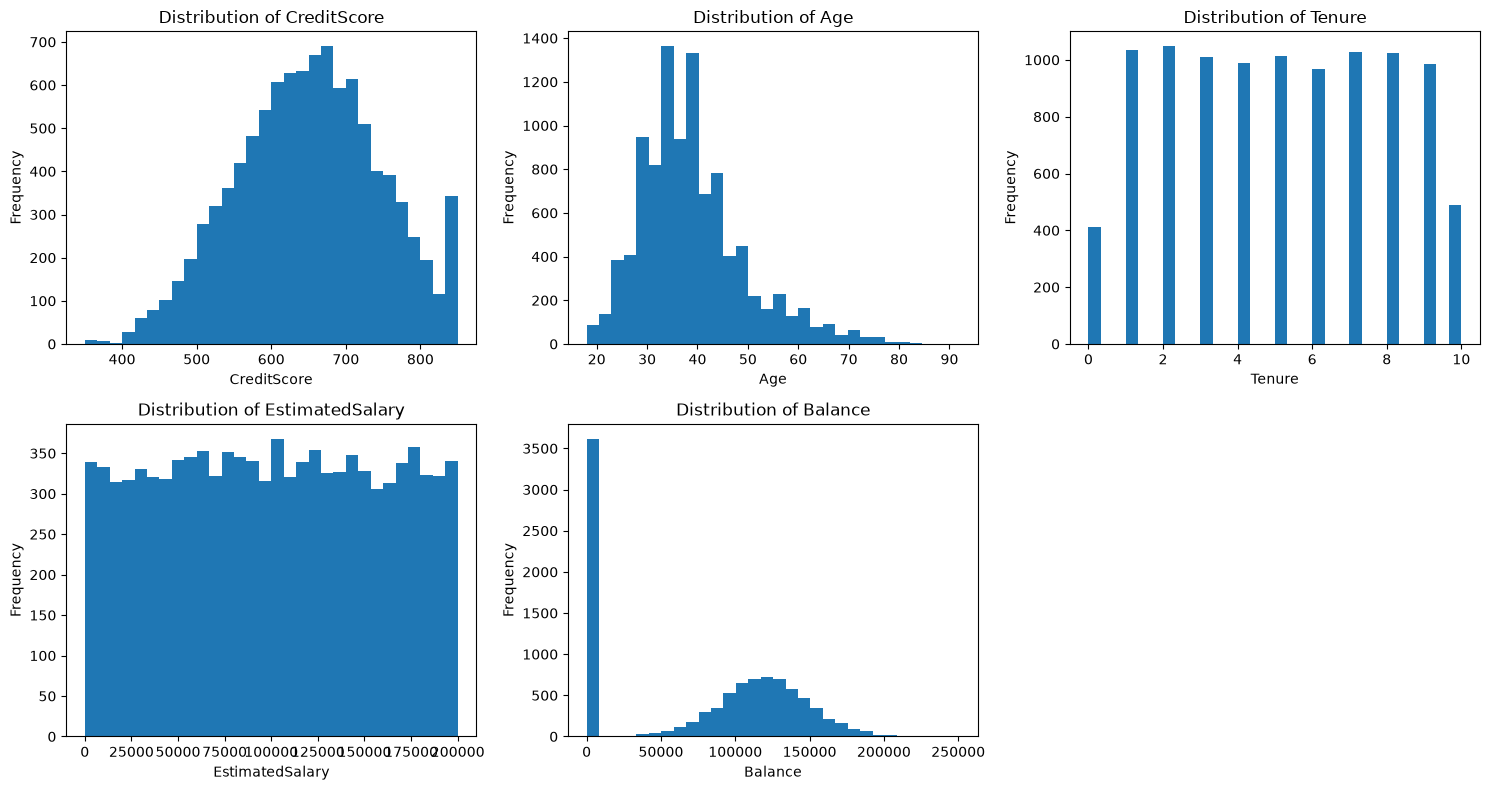

In [295]:
import matplotlib.pyplot as plt

numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "EstimatedSalary",
    "Balance"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_merged[col], bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide the unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()